<br>

<div align="center">
<h1>Использование языка программирования Julia для решения математических задач
<br> 
<br> 
Часть II</h1>
</div>

<br>

<br>

<br>

<br>

<br>

<br>


<br>

**<span style="font-size: 1.1em">Авторы:</span>** 

**Чуракова Юлия Романовна**  
*Студентка факультета математики и компьютерных наук*  
*Кубанского Государственного Университета*

**<span style="font-size: 1.1em"></span>** **Алексеев Евгений Ростиславович**  
*Кандидат технических наук, доцент*  
*Доцент кафедры информационных технологий*  
*Кубанского Государственного Университета*


<br>

<br>

<br>

<br>

<br>

<br>

<br>

---


**Полная версия пособия доступна в репозитории:** [https://github.com/JuliaChurakova/Julia](https://github.com/JuliaChurakova/Julia)

---

# Литература
1. Алексеев, Е. Р. Scilab: Решение инженерных и математических задач: учеб. издание. / Е.Р. Алексеев, К. В. Дога, О. В. Чеснокова М. – Базальт СПО; ДМК Пресс, 2024. – 440 с.
2. Балакин, А. А. Численные методы и математическое моделирование: Учебное пособие / А.А. Балакин. – Долгопрудный: Издательский Дом «Интеллект», 2022. – 288 с.
3. Деза, Е. И. Введение в криптографию: Теоретико-числовые основы защиты информации. Учебное пособие / Е. И. Деза, Л. В. Котова. – Москва: ЛЕНАНД, 2022. – 376 с.
4. Кнауб, Л. В. Теоретико-численные методы в криптографии / Л. В. Кнауб, Е. А. Новиков, Ю. А. Шитов; Сибирский федеральный университет – Красноярск: 2011. – 160 с.

# Глава 17 Нелинейные уравнения и системы в Julia
## 17.1 Методы решения нелинейных уравнений
При решении нелинейных уравнений вида f(x) = 0, где f(x) может быть как алгебраической, так и трансцендентной функцией (содержащей экспоненты, логарифмы или тригонометрические функции), аналитическое решение часто невозможно. В таких случаях применяются численные методы.

### 17.1.1 Решение нелинейных и трансцендентных уравнений

Процесс решения состоит из двух ключевых этапов:

1. **локализация корней** – поиск интервалов [a, b], где функция пересекает ось абсцисс. Согласно теореме Больцано-Коши, если непрерывная функция меняет знак на концах интервала $(f(a) \cdot f(b) < 0)$, то внутри обязательно существует корень;

2. **уточнение корней** – вычисление значения корня с заданной точностью ε с использованием различных численных методов.

Для понимания поведения функции и предварительной оценки местоположения корней крайне полезно построить её график. Рассмотрим пример уравнения:

$$f(x) = x^2 - cos(5x)$$


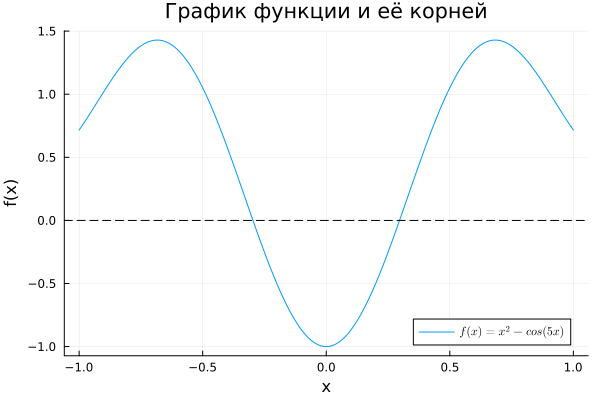

In [10]:
using Plots
f(x) = x^2 - cos(5x)
plot(-1:0.01:1, f, label="\$f(x) = x^2 - cos(5x)\$")
hline!([0], color=:black, linestyle=:dash, label="")
xlabel!("x"); ylabel!("f(x)")
title!("График функции и её корней")

Из графика видно, что функция пересекает ось X дважды, значит уравнение имеет два корня, расположенных приблизительно в интервалах [-0.4, -0.2] и [0.2, 0.4].


На интервале изоляции корня функция f(x) должна удовлетворять следующим условиям:
1) функция f(x) непрерывна вместе со своими производными первого
и второго порядка;

3) функция f(x) на концах интервала [a, b] имеет разные знаки $f(a) \cdot f(b) <
0$;
4) первая и вторая производные $f'(x)$ и $f''(x)$ сохраняют определённый
знак на всём интервале [a, b].

#### 17.1.1.1 Метод половинного деления
Метод половинного деления является простейшим алгоритмом поиска корней. Его геометрическая интерпретация основана на последовательном сужении интервала, содержащего корень, путем деления его пополам. Ключевое преимущество метода – гарантированная сходимость для любой непрерывной функции, меняющей знак на концах интервала. Однако скорость сходимости относительно невысока, что делает метод менее эффективным по сравнению с более сложными алгоритмами.

Алгоритм метода половинного деления:

1) вычисляем середину интервала $c = \frac{a + b}{2}$;
2) находим значение f(c);
3) проверяем условие $f(a) \cdot f(c) < 0$:
   - если выполняется, корень находится в $[a, c]$;
   - иначе - в $[c, b]$.
4) если величина интервала меньше либо равна $\epsilon$, то корень найден,
иначе возвращаемся к п. 1.

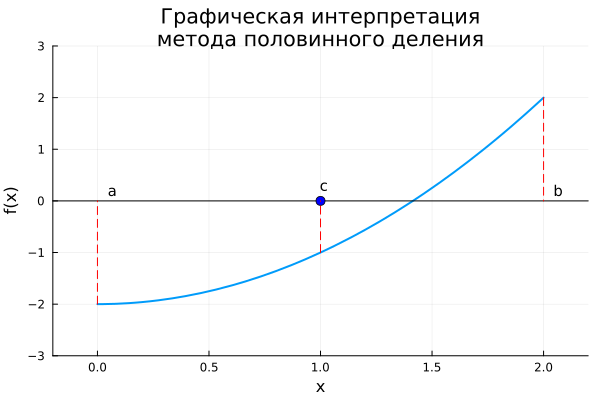

In [6]:
using Plots

# Определяем функцию
f(x) = x^2 - 2

# Начальный интервал 
a, b = 0.0, 2.0 
c = (a + b)/2  # середина

# Создаем основной график
p = plot(f, 0, 2, label="", linewidth=2, legend=:topleft)

# Ось X
hline!([0], label="", color=:black, linestyle=:solid)


# Середина интервала
scatter!([c], [0], label="", color=:blue, markersize=5)

# Пунктирные линии до оси X
plot!([a, a], [f(a), 0], color=:red, linestyle=:dash, label="")
plot!([b, b], [f(b), 0], color=:red, linestyle=:dash, label="")
plot!([c, c], [f(c), 0], color=:red, linestyle=:dash, label="")

annotate!(a+0.05, 0.2, text("a", 10, :left))
annotate!(b+0.05, 0.2, text("b", 10, :left))
annotate!(c, 0.3, text("c", 10, :left))


title!("Графическая интерпретация
метода половинного деления")
xlabel!("x")
ylabel!("f(x)")
xlims!(minimum([a,b])-0.2, maximum([a,b])+0.2)
ylims!(-3, 3)

#### 17.1.1.2 Метод хорд

Метод хорд представляет собой модификацию метода половинного деления, где новое приближение вычисляется не как середина интервала, а как точка пересечения с осью X хорды, проведенной через точки графика функции.

Уравнение хорды через точки $(a, f(a))$ и $(b, f(b))$:
$$
\frac{y - f(a)}{f(b) - f(a)} = \frac{x - a}{b - a}
$$

Нас интересует точка C(c, 0), где прямая пересекает ось абсцисс (y = 0).

Подставляем y = 0:
$$
\frac{0 - f(a)}{f(b) - f(a)} = \frac{c - a}{b - a}
$$

Значит, $c =  a - \frac{f(a)}{f(a) - f(b)} (b - a)$

Алгоритм метода хорд:
1. вычисляем точку $c$ по приведенной формуле;
2. проверяем условие $f(a) \cdot f(c) < 0$:
   - если выполняется, корень находится в $[a, c]$;
   - иначе - в $[c, b]$.
3. итерации продолжаются до достижения условия $|f(c)| < \epsilon$.

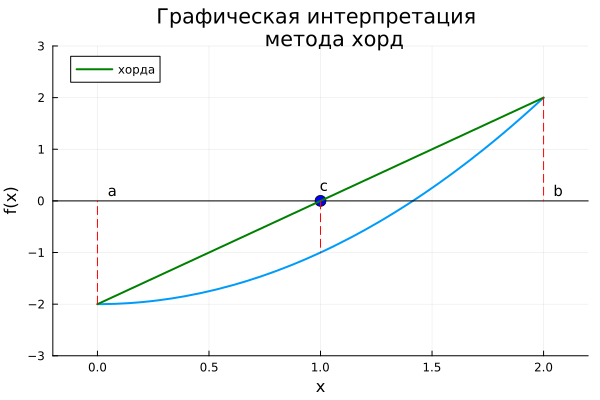

In [1]:
using Plots

# Определяем функцию
f(x) = x^2 - 2

# Начальный интервал
a, b = 0.0, 2.0
c = a - f(a)*(b - a)/(f(b) - f(a))  # Формула метода хорд

# Создаем основной график
p = plot(f, 0, 2, label="", linewidth=2, legend=:topleft)

# Ось X
hline!([0], label="", color=:black, linestyle=:solid)


# Точка пересечения хорды
scatter!([c], [0], label="", color=:blue, markersize=6)

# Хорда (секущая)
plot!([a, b], [f(a), f(b)], color=:green, linestyle=:solid, label="хорда", linewidth=2)

# Пунктирные линии до оси X
plot!([a, a], [f(a), 0], color=:red, linestyle=:dash, label="")
plot!([b, b], [f(b), 0], color=:red, linestyle=:dash, label="")
plot!([c, c], [0, f(c)], color=:red, linestyle=:dash, label="")

annotate!(a+0.05, 0.2, text("a", 10, :left))
annotate!(b+0.05, 0.2, text("b", 10, :left))
annotate!(c, 0.3, text("c", 10, :left))


# Настройки отображения
title!("Графическая интерпретация 
    метода хорд")
xlabel!("x")
ylabel!("f(x)")
xlims!(minimum([a,b])-0.2, maximum([a,b])+0.2)
ylims!(-3, 3)

#### 17.1.1.3 Метод Ньютона (касательных)

В одной из точек интервала [a; b], пусть это будет точка c, проведём касательную. Уравнение этой прямой: $y = k \cdot x + m$.

Так как эта прямая является касательной и проходит через точку $(c , f(c))$, то $k = f'(c)$.
Следовательно,
$$y = f'(x) \cdot x + m, f(c) = f'(c) \cdot c + m, m = f(c) - c \cdot f'(c),$$
$$y = f'(c) \cdot x + f(c) - c \cdot f'(c), y = f'(c) \cdot (x - c) + f(c).$$

Найдём точку пересечения касательной с осью X : 
$$f'(c) \cdot (x - c) + f(c) = 0,$$
$$x = c - \frac{f(c)}{f'(c)}.$$

Если $|f(х)| < \epsilon$, то точность достигнута и точка x – решение, иначе необходимо переменной c присвоить значение x и провести касательную через новую точку c, так продолжать до тех пор, пока |f(x)| не станет меньше ε.

Выбор начальной точки в методе Ньютона требует соблюдения важного условия: значения функции и её второй производной в этой точке должны быть одного знака. 

Поскольку мы предполагаем, что первая и вторая производные не меняют свой знак на рассматриваемом интервале, достаточно проверить условие $f(x)\cdot f''(x) > 0$ на концах отрезка [a, b]. В качестве начального приближения следует выбрать тот конец интервала, где это неравенство выполняется.

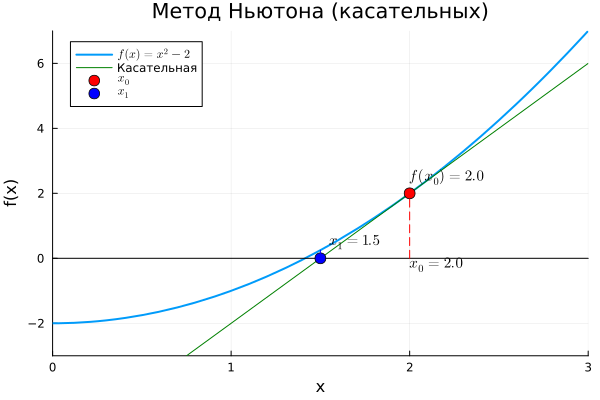

In [8]:
using Plots

# Определяем функцию и производные
f(x) = x^2 - 2
df(x) = 2x   # Первая производная
d2f(x) = 2   # Вторая производная

# Выбираем начальную точку согласно условию f(x)*f''(x) > 0
a, b = 0.0, 2.0
x0 = f(a)*d2f(a) > 0 ? a : b  # Проверяем условие на концах интервала

# Вычисляем первое приближение
x1 = x0 - f(x0)/df(x0)

# Создаем график
plot(f, 0, 3, label="\$f(x) = x^2 - 2\$", linewidth=2, legend=:topleft)

# Ось X
hline!([0], label="", color=:black, linestyle=:solid)

# Касательная в точке x0
tangent(x) = df(x0)*(x - x0) + f(x0)
plot!(0:0.01:3, tangent, label="Касательная", color=:green, linestyle=:solid)

# Точки и их проекции
scatter!([x0], [f(x0)], label="\$x_0\$", color=:red, markersize=6)
scatter!([x1], [0], label="\$x_1\$", color=:blue, markersize=6)

# Пунктирные линии
plot!([x0, x0], [0, f(x0)], color=:red, linestyle=:dash, label="")
plot!([x1, x1], [0, f(x1)], color=:blue, linestyle=:dash, label="")

# Аннотации
annotate!(x0, -0.2, text("\$ x_0 = $x0 \$", 10, :left))
annotate!(x1+0.05, 0.5, text("\$ x_1 = $(round(x1, digits=4)) \$", 10, :left))
annotate!(x0, f(x0)+0.5, text("\$f(x_0) = $(round(f(x0), digits=4))\$", 10, :left))

# Настройки отображения
title!("Метод Ньютона (касательных)")
xlabel!("x")
ylabel!("f(x)")
xlims!(0, 3)
ylims!(-3, 7)

#### 17.1.1.4 Метод простой итерации

Для применения метода простой итерации необходимо преобразовать исходное уравнение $f(x) = 0$ к эквивалентному виду:
$$
x = \phi(x)
$$

Итерационный процесс задается формулой:
$$
x_{k+1} = \phi(x_k), \quad k = 0, 1, 2, \ldots
$$
Вычисления прекращаются при достижении условия $|x_{k+1} - x_k| < \epsilon$, где $\epsilon$ – заданная точность.

Достаточным условием сходимости является выполнение неравенства:
$$
|\phi'(x)| < 1 \quad \text{для всех} \quad x \in [a, b]
$$

Исходное уравнение можно привести к нужному виду следующим способом:
1. умножаем обе части на параметр $\lambda$:
   $$
   \lambda f(x) = 0
   $$
2. добавляем $x$ к обеим частям:
   $$
   x = x + \lambda f(x)
   $$
   
Таким образом, итерационная функция принимает вид:
$$
\phi(x) = x + \lambda f(x)
$$

Для обеспечения сходимости необходимо:
$$
|1 + \lambda f'(x)| < 1
$$

#### 19.1.1.5 Метод секущих
Метод секущих представляет собой итерационный процесс нахождения корня, в котором каждое новое приближение вычисляется на основе двух предыдущих точек.

Уравнение секущей, проходящей через точки $(x_k, f(x_k))$ и $(x_{k+1}, f(x_{k+1}))$:
   $$
   \frac{y - f(x_k)}{f(x_{k+1}) - f(x_k)} = \frac{x - x_k}{x_{k+1} - x_k}
   $$

Точка пересечения с осью OX ($y = 0$):
   $$
   x_{k+2} = x_{k+1} - f(x_{k+1}) \cdot \frac{x_{k+1} - x_k}{f(x_{k+1}) - f(x_k)}, k = 0,1,2,...
   $$

Итерационный процесс продолжается до выполнения условия:
   $$
   |f(x_{k+2})| < \epsilon,
   $$
   где $\epsilon$ – заданная точность вычислений.


Метод половинного деления:
x = 2.094551481306553, f(x) = -2.6315731815884646e-9, итераций: 27

Метод хорд:
x = 2.094551480976474, f(x) = -6.3157301610772265e-9, итераций: 19

Метод секущих:
x = 2.0945514816982445, f(x) = 1.7402674856725753e-9, итераций: 3

Метод Ньютона:
x = 2.0945514815423474, f(x) = 2.327027459614328e-13, итераций: 5

Метод простой итерации:
x = 2.094551481727466, f(x) = 2.066421700419596e-9, итераций: 9


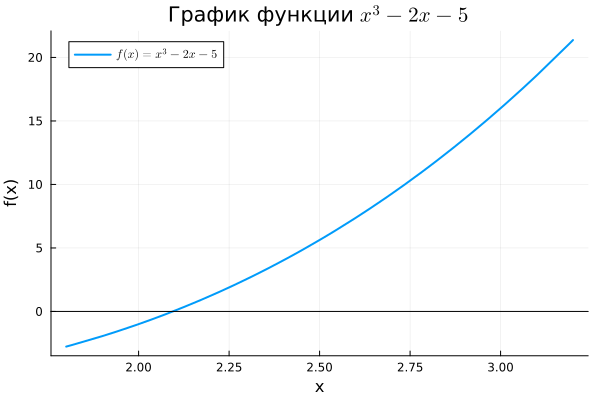

In [2]:
using Plots

# Определяем функцию и её производные
f(x) = x^3 - 2x - 5
df(x) = 3x^2 - 2    # Первая производная
d2f(x) = 6x         # Вторая производная

# Метод половинного деления
function dihotomy(a, b, eps)
    k = 0
    c = 0
    while abs(b - a) > eps
        k += 1
        c = (a + b)/2
        f(a)*f(c) < 0 ? (b = c) : (a = c)
        if abs(f(c)) < eps 
            break
        end
    end
    return (c, k)
end

# Метод хорд
function chord(a, b, eps)
    k = 0
    c = a - f(a)*(b - a)/(f(b) - f(a))
    while abs(f(c)) > eps
        k += 1
        c = a - f(a)*(b - a)/(f(b) - f(a))
        f(a)*f(c) < 0 ? (b = c) : (a = c)
    end
    return (c, k)
end

# Метод секущих
function secant(x0, x1, eps)
    k = 0
    while abs(f(x1)) > eps
        k += 1
        x2 = x1 - f(x1)*(x1 - x0)/(f(x1) - f(x0))
        x0, x1 = x1, x2
    end
    return (x1, k)
end

# Метод Ньютона (касательных)
function newton(a, b, eps)
    k = 0
    f(a)*d2f(a) < 0 ? (c = b) : (c = a)
    while abs(f(c)) > eps
        k += 1
        c = c - f(c)/df(c)
    end
    return (c, k)
end

# Метод простой итерации
function simple_iteration(x0, lambda, eps)
    k = 0
    x = x0
    while abs(f(x)) > eps
        k += 1
        x = x + lambda*f(x)
    end
    return (x, k)
end

# Интервал изоляции корня [2, 3]
a, b = 2.0, 3.0
eps = 1e-8

# Подбираем λ для метода простой итерации
lambda = -0.1  

# Вычисляем корни разными методами
res_dih = dihotomy(a, b, eps)
res_ch = chord(a, b, eps)
res_sec = secant(2.0, 2.1, eps)
res_newt = newton(a, b, eps)
res_iter = simple_iteration(2.0, lambda, eps)

# Выводим результаты
println("Метод половинного деления:")
println("x = ", res_dih[1], ", f(x) = ", f(res_dih[1]), ", итераций: ", res_dih[2])
println("\nМетод хорд:")
println("x = ", res_ch[1], ", f(x) = ", f(res_ch[1]), ", итераций: ", res_ch[2])
println("\nМетод секущих:")
println("x = ", res_sec[1], ", f(x) = ", f(res_sec[1]), ", итераций: ", res_sec[2])
println("\nМетод Ньютона:")
println("x = ", res_newt[1], ", f(x) = ", f(res_newt[1]), ", итераций: ", res_newt[2])
println("\nМетод простой итерации:")
println("x = ", res_iter[1], ", f(x) = ", f(res_iter[1]), ", итераций: ", res_iter[2])
# Строим график
plot(f, 1.8, 3.2, label="\$f(x) = x^3 - 2x - 5\$", linewidth=2)
hline!([0], label="", color=:black)
title!("График функции \$x^3 - 2x - 5\$")
xlabel!("x")
ylabel!("f(x)")


### 17.1.2 Особенности решения алгебраических уравнений
Алгебраическое уравнение (полиномиальное уравнение) – уравнение вида:
$$
P_1x^n + P_2x^{n-1} + \cdots + P_nx + P_{n+1} = 0,
$$
где $P_1 \neq 0$, $n \geq 1$, а $P_i$ – коэффициенты полинома n-й степени.

**Примеры**:
- линейное уравнение ($n=1$): $ax + b = 0$;
- квадратное уравнение ($n=2$): $ax^2 + bx + c = 0$;
- кубическое уравнение ($n=3$): $ax^3 + bx^2 + cx + d = 0$.

Для нахождения полного набора корней полиномиального уравнения n-й степени применяется итерационный подход, основанный на последовательном выделении корней (при помощи метода Мюллера) с последующим понижением степени (схема Горнера) исходного полинома. В общем случае многочлен n-й степени имеет n корней, некоторые из них могут быть комплексными.

#### 17.1.2.1 Метод Мюллера (парабол)

Метод Мюллера представляет собой итерационный алгоритм нахождения корней полиномиальных уравнений. Для работы метода требуются три точки начальныого приближения: $x_0, x_1 и x_2$, в которых вычисляются соответствующие значения функции $y_0 = f(x_0),\quad y_1 = f(x_1) \quad \text{и} \quad y_2 = f(x_2)$. На каждой итерации строится парабола вида $y = a \cdot x^2 + b \cdot x + c$, проходящая через эти три точки, и находится её пересечение с осью абсцисс, которое становится новым приближением.

Cледующее приближение рассчитывается по формуле:

$$x = x_0- \frac{2 \cdot f(x_0)}{ω ± \sqrt{ω^2 - 4 \cdot f(x_0) \cdot y_{012}}}$$

Знак «+» или «-» в формуле выбирается таким образом, чтобы знаменатель в был больше.

ω вычисляется по формуле $ω = y_{01} + y_{02} - y_{12} $, где 
$$y_{01} = \frac{y_0-y_1}{x_0-x_1}, y_{02} = \frac{y_0-y_2}{x_0-x_2}, y_{12} = \frac{y_1-y_2}{x_1-x_2}$$
– разделенные разности первого порядка;
$$y_{123} = \frac{y_{12}-y_{01}}{x_0-x_2}$$
– разделенные разности второго порядка.

Процесс повторяется до достижения заданной точности $|f(x)| < \epsilon$.


#### 17.1.2.2 Метод обратной параболы

Через три заданные точки $(x_0, f(x_0))$, $(x_1, f(x_1))$ и $(x_2, f(x_2))$ проводится парабола вида:

$$
x = a \cdot y^2 + b \cdot y + c,
$$

где коэффициенты $a$, $b$ и $c$ определяются следующими формулами:

$$
a = \frac{(x_2 - x_2)(f(x_1) - f(x_0)) - (x_1 - x_0)(f(x_2) - f(x_1))}{(f(x_2) - f(x_1))(f(x_1) - f(x_0))(f(x_2) - f(x_0))},
$$

$$
b = - a(f(x_2) + f(x_1))\frac{x_2 - x_0 }{f(x_2) - f(x_1)}.
$$

Новое приближение корня вычисляется как свободный член $c$:

$$
x_{n+1} = c = x_2 - a \cdot f(x_2)^2 - b \cdot f(x_2)
$$

После вычисления нового приближения выполняется обновление точек:
$$
\begin{align*}
x_0 &= x_1 \\
x_1 &= x_2 \\
x_2 &= c
\end{align*}
$$
с соответствующим пересчетом значений функции $f(x_0)$, $f(x_1)$ и $f(x_2)$. Итерационный процесс продолжается до достижения заданной точности:

$$
|f(x_2)| < \epsilon
$$


#### 17.1.2.3 Понижение порядка полинома (деление на линейный множитель)

Для полинома степени n:

$$
P(x) = \sum_{k=0}^n p_k x^{n-k} = p_0 x^n + p_1 x^{n-1} + \cdots + p_{n-1} x + p_n,
$$

после нахождения корня $\alpha$ выполняется деление на $(x - \alpha)$, что дает полином степени $n-1$:

$$
P(x) = (x - \alpha)Q(x) + R,
$$

где $Q(x) = \sum_{k=0}^{n-1} b_k x^{n-1-k}$ – частное, а $R$ – остаток.

#### 17.1.2.4 Схема Горнера
Схема Горнера представляет собой алгоритм вычисления значения полинома в заданной точке. Рассмотрим полином n-й степени общего вида:

$$
f(x) = P_1x^n + P_2x^{n-1} + \cdots + P_nx + P_{n+1}
$$

Для конкретного примера возьмем полином 4-й степени:

$$
f(x) = P_1x^4 + P_2x^3 + P_3x^2 + P_4x + P_5,
$$

схема Горнера позволяет переписать его в виде вложенных умножений:

$$
f(x) = P_5 + x(P_4 + x(P_3 + x(P_2 + xP_1)))
$$

Вычислительный процесс реализуется следующим образом:
1. начинаем со старшего коэффициента: $b = P_1$;
2. последовательно добавляем младшие коэффициенты:
   $$
   b = P_2 + x*b,
   $$
   $$
   b = P_3 + x*b,
   $$
   $$
   b = P_4 + x*b,
   $$
   $$
   b = P_5 + x*b. 
   $$


In [10]:
using Printf

# Функция вычисления разделённой разности первого порядка
function razd(x1, x2, f1, f2)
    return (f2 - f1) / (x2 - x1)
end

# Функция вычисления разделённой разности второго порядка
function razd2(x0, x1, x2, f0, f1, f2)
    return (razd(x1, x2, f1, f2) - razd(x0, x1, f0, f1)) / (x0 - x2)
end

# Функция вычисления значения полинома в точке по схеме Горнера
function gr(P, x0)
    y0 = zero(ComplexF64)
    for i in 1:length(P)
        y0 = P[i] + x0 * y0
    end
    return y0
end

# Функция понижения порядка полинома
function delenie_gorner(P, alfa)
    N = length(P)
    B = zeros(ComplexF64, N-1)
    B[1] = P[1]
    for i in 2:N-1
        B[i] = B[i-1] * alfa + P[i]
    end
    return B
end

# Функция нахождения очередного корня полинома методом Мюллера (парабол)
function Muller(P, x1; max_iter=1000, tol=1e-10)
    x2 = 1.15 * x1
    x0 = 0.85 * x1
    f0 = gr(P, x0)
    f1 = gr(P, x1)
    f2 = gr(P, x2)
    x = x2
    
    iter = 0
    while abs(gr(P, x)) > tol && iter < max_iter
        iter += 1
        
        u = razd(x0, x1, f0, f1) + razd(x0, x2, f0, f2) - razd(x1, x2, f1, f2)
        t1 = u - sqrt(u*u - 4.0*f0*razd2(x0, x1, x2, f0, f1, f2))
        t2 = u + sqrt(u*u - 4.0*f0*razd2(x0, x1, x2, f0, f1, f2))
        
        t = abs(t1) > abs(t2) ? t1 : t2
        x_new = x0 - 2 * gr(P, x0) / t
        x2, x1, x0 = x1, x0, x_new
        f0 = gr(P, x0)
        f1 = gr(P, x1)
        f2 = gr(P, x2)
        x = x_new
    end
    
    if iter == max_iter
        println("Достигнуто максимальное количество итераций для корня $x")
    end
    
    return x
end

# Функция нахождения всех корней полинома методом Мюллера
function korni_polynom(P)
    N = length(P)
    roots = ComplexF64[]
    current_P = copy(P)
    
    println("Корни полинома методом Мюллера:")
    t = 1
    while N > 1
        x = Muller(current_P, 1.0 + 0.1im)
        
        if abs(imag(x)) < 1e-10
            @printf("x%d = %15.10f\n", t, real(x))
        else
            @printf("x%d = %15.10f %+15.10fi\n", t, real(x), imag(x))
        end
        
        push!(roots, x)
        current_P = delenie_gorner(current_P, x)
        N -= 1
        t += 1
    end
    
    return roots
end

# Функция нахождения очередного корня полинома методом обратной параболы
function obr_parabol(P, x1; max_iter=1000, tol=1e-10)
    x2 = 1.15 * x1
    x0 = 0.85 * x1
    f0 = gr(P, x0)
    f1 = gr(P, x1)
    f2 = gr(P, x2)
    
    iter = 0
    while abs(f2) > tol && iter < max_iter
        iter += 1
        
        denom = (f2 - f1) * (f1 - f0) * (f2 - f0)        
        a = ((x2 - x1)*(f1 - f0) - (x1 - x0)*(f2 - f1)) / denom
        b = -a * (f2 + f1) + (x2 - x1) / (f2 - f1)
        c = x2 - a*f2^2 - b*f2
        
        x0, x1, x2 = x1, x2, c
        f0 = gr(P, x0)
        f1 = gr(P, x1)
        f2 = gr(P, x2)
    end
    
    if iter == max_iter
        error("Метод обратной параболы не сошелся за $max_iter итераций")
    end
    
    return x2
end

# Функция нахождения всех корней методом обратной параболы
function korni_obr_parabola(P)
    N = length(P)
    roots = ComplexF64[]
    current_P = copy(P)
    
    println("Корни полинома методом обратной параболы:")
    t = 1
    while N > 1
        x = obr_parabol(current_P, 1.0 + 0.1im)
        if abs(imag(x)) < 1e-10
            @printf("x%d = %15.10f\n", t, real(x))
        else
            @printf("x%d = %15.10f %+15.10fi\n", t, real(x), imag(x))
        end
            push!(roots, x)
            current_P = delenie_gorner(current_P, x)
            N -= 1
            t += 1
    end
    
    return roots
end

# Задание коэффициентов тестового полинома 
H = ComplexF64[1, -3.53, 5.5008, -5.005746,	2.9592021,	-1.1938382,	0.3353804,	-0.0655751,	0.0087373,	-0.0007545,	0.0000379,	-0.00000080]

println("Коэффициенты: ", H)

@time roots_muller = korni_polynom(H)
@time roots_parabola = korni_obr_parabola(H)

Коэффициенты: ComplexF64[1.0 + 0.0im, -3.53 + 0.0im, 5.5008 + 0.0im, -5.005746 + 0.0im, 2.9592021 + 0.0im, -1.1938382 + 0.0im, 0.3353804 + 0.0im, -0.0655751 + 0.0im, 0.0087373 + 0.0im, -0.0007545 + 0.0im, 3.79e-5 + 0.0im, -8.0e-7 + 0.0im]
Корни полинома методом Мюллера:
x1 =    0.7700033600
x2 =    0.4971933954   +0.0000005217i
x3 =    0.0566453965   -0.0000009967i
x4 =    0.3404927577   +0.1578455392i
x5 =    0.2086748340   -0.1514456045i
x6 =    0.4523851742   -0.1029660014i
x7 =    0.4523845348   +0.1029671260i
x8 =    0.1015278013   -0.0894153342i
x9 =    0.1015258884   +0.0894138203i
x10 =    0.3404944255   -0.1578445873i
x11 =    0.2086724323   +0.1514455169i
  0.090737 seconds (81.16 k allocations: 3.801 MiB, 99.65% compilation time)
Корни полинома методом обратной параболы:
x1 =    0.7700033601
x2 =    0.4972000625   +0.0000001818i
x3 =    0.1015195084   +0.0894221581i
x4 =    0.3404969299   +0.1578557733i
x5 =    0.3404990371   -0.1578548374i
x6 =    0.1015184632   -0.08942320

11-element Vector{ComplexF64}:
  0.7700033601030573 + 8.711201771646372e-12im
  0.4972000625000879 + 1.8184318289227197e-7im
  0.1015195083836618 + 0.08942215810012516im
 0.34049692991079006 + 0.1578557732770404im
  0.3404990370997725 - 0.15785483741243436im
 0.10151846322997195 - 0.08942320309255318im
 0.45239148462307427 + 0.1029715766750723im
  0.4523915755797437 - 0.10297039222145593im
 0.05663671154444955 + 4.6065415052746976e-7im
 0.20867058206052963 + 0.15145707241232337im
 0.20867228496485946 - 0.15145879024416248im

## 17.2 Библиотеки Julia для решения нелинейных уравнений
### 17.2.1 Решение алгебраических трансцендентных уравнений

Для решения полиномиальных уравнений оптимальным выбором будет пакет **PolynomialRoots.jl**. Он предоставляет точные численные методы для нахождения корней полиномов любой степени.

Для получения дополнительной информации о пакете см. [документацию.](https://github.com/giordano/PolynomialRoots.jl)

In [2]:
using PolynomialRoots
# x^3 - 2x^2 - x + 2
roots([2, -1, -2, 1])

3-element Vector{ComplexF64}:
  2.0 - 0.0im
 -1.0 + 0.0im
  1.0 + 0.0im

In [23]:
using PolynomialRoots

# x^4 - 35x^3 + 280x^2 - 1350x + 1000
roots([1000.0, -0.0, 280.0, -35.0, 1.0]) 

4-element Vector{ComplexF64}:
   22.425602847087568 + 4.507003580275866e-16im
   12.991648800467265 - 8.947895678776494e-16im
 -0.20862582377741662 - 1.8408762965878802im
 -0.20862582377741676 + 1.8408762965878807im

Для решения алгебраических и трансцендентных уравнений лучше использовать **Roots.jl**.

Для получения дополнительной информации о пакете см. [документацию.](https://github.com/giordano/PolynomialRoots.jl)

**Основные функции**:
- find_zero(f, x0) – поиск корня от начальной точки или интервала;
- find_zeros(f, a, b) – поиск всех корней на интервале [a, b].

**Методы**:
- Bisection() – метод деления пополам (требует f(a)*f(b) < 0);
- Newton() – метод Ньютона (нужна производная);
- Brent() – гибридный алгоритм, сочетающий метод деления пополам, линейную интерполяцию и обратную квадратичную интерполяцию;
- Secant() – метод секущих;
- Order1() – метод обратной квадратичной интерполяции.



Пример 1: решение x^3 - 2x - 5 = 0 разными методами 
Метод Брента: 2.09455148
Метод Ньютона: 2.09455148
Метод секущих: 2.09455148

Пример 2: все корни sin(10x) - x/2 = 0 на [-3, 3] 
Найдено 11 корней:
[-1.48697, -1.329342, -0.896024, -0.662058, -0.299146, 0.0, 0.299146, 0.662058, 0.896024, 1.329342, 1.48697]


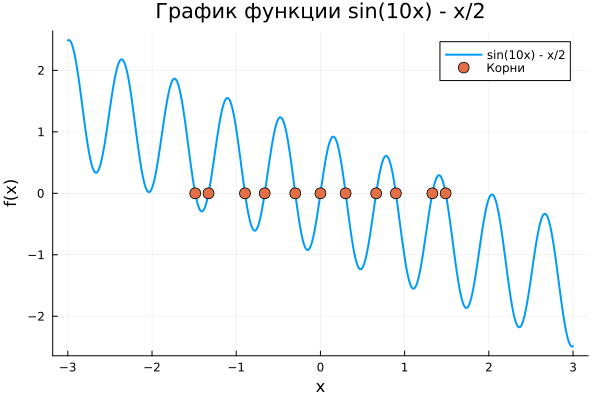


Пример 3: решение cos(x) - x = 0 методом бисекции 
Метод бисекции: 0.73908513

Пример 4: решение exp(-x) - log(x) = 0 

Корень exp(-x) - log(x): 1.3097995858041505


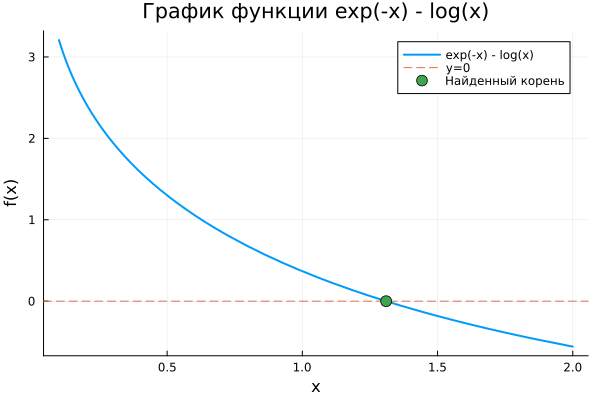

In [10]:
using Roots
using Plots
using Roots: Brent, Newton, Secant, Bisection, Order1



println("\nПример 1: решение x^3 - 2x - 5 = 0 разными методами ")
f(x) = x^3 - 2x - 5

# Метод Брента
root_brent = find_zero(f, (2.0, 3.0), Brent())
println("Метод Брента: ", round(root_brent, digits=8))
# Метод Ньютона
df(x) = 3x^2 - 2
root_newton = find_zero((f, df), 2.0, Newton())
println("Метод Ньютона: ", round(root_newton, digits=8))

# Метод секущих
root_secant = find_zero(f, (2.0, 3.0), Secant())
println("Метод секущих: ", round(root_secant, digits=8))

println("\nПример 2: все корни sin(10x) - x/2 = 0 на [-3, 3] ")
g(x) = sin(10x) - x/2
g_str = "sin(10x) - x/2"

all_roots = find_zeros(g, -3.0, 3.0)
println("Найдено ", length(all_roots), " корней:")
println(round.(all_roots, digits=6))

# Визуализация
p = plot(g, -3, 3, label=g_str, linewidth=2, legend=:topright)
scatter!(all_roots, zeros(length(all_roots)), label="Корни", markersize=6)
title!("График функции $g_str")
xlabel!("x")
ylabel!("f(x)")
display(p)

println("\nПример 3: решение cos(x) - x = 0 методом бисекции ")
h(x) = cos(x) - x
h_str = "cos(x) - x"

root_bisect = find_zero(h, (0.0, 1.0), Bisection())
println("Метод бисекции: ", round(root_bisect, digits=8))


println("\nПример 4: решение exp(-x) - log(x) = 0 ")
k(x) = exp(-x) - log(x)
k_str = "exp(-x) - log(x)"

# Численное решение
root_k = find_zero(k, (0.5, 1.5), Order1())
# Графический анализ
p2 = plot(k, 0.1, 2, label=k_str, linewidth=2)
hline!([0], label="y=0", linestyle=:dash)
title!("График функции $k_str")
xlabel!("x")
ylabel!("f(x)")
println("\nКорень exp(-x) - log(x): ", root_k)
scatter!([root_k], [0], label="Найденный корень", markersize=6)

### 17.2.1 Решение систем нелинейных уравнений


Для решения системы уравнений вида F(x)=0 можно использовать функцию **nlsolve()** из пакета NLsolve.

Для получения дополнительной информации о пакете см. [документацию.](https://docs.sciml.ai/NonlinearSolve/stable/api/nlsolve/)

In [12]:
using NLsolve

function f(x)
    [(x[1] + 3) * (x[2]^3 - 7) + 18,
     sin(x[2] * exp(x[1]) - 1)]
end

sol = nlsolve(f, [0.1, 1.2])  # Начальное приближение [0.1, 1.2]
println("Решение: ", sol.zero)

Решение: [-7.775548712324193e-17, 0.9999999999999999]


Для большей эффективности можно задать якобиан вручную.

In [13]:
function f!(F, x)
    F[1] = (x[1] + 3) * (x[2]^3 - 7) + 18
    F[2] = sin(x[2] * exp(x[1])) - 1
end

function j!(J, x)
    J[1,1] = x[2]^3 - 7
    J[1,2] = 3 * x[2]^2 * (x[1] + 3)
    u = exp(x[1]) * cos(x[2] * exp(x[1]) - 1)
    J[2,1] = x[2] * u
    J[2,2] = u
end

sol = nlsolve(f!, j!, [0.1, 1.2])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [0.1, 1.2]
 * Zero: [0.2885804649763026, 1.1514182421994206]
 * Inf-norm of residuals: 0.000584
 * Iterations: 1000
 * Convergence: false
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: false
 * Function Calls (f): 87
 * Jacobian Calls (df/dx): 47

**Основные алгоритмы:**
- метод доверительной области (:trust_region, по умолчанию).
- метод Ньютона (:newton) с опциональным линейным поиском.
- ускорение Андерсона (:anderson) для задач с фиксированной точкой.

Пример выбора метода:

In [ ]:
nlsolve(f!, [0.1, 1.2], method = :newton)

In [14]:
using NLsolve

# Определяем систему уравнений
function system!(F, x)
    F[1] = x[1]^2 + x[2]^2 - 1     # Окружность x^2 + y^2 = 1
    F[2] = exp(x[1]) - x[2]^3       # exp(x) = y^3
end

# Определяем якобиан (матрицу производных)
function jacobian!(J, x)
    J[1,1] = 2*x[1]      # ∂F_1/∂x
    J[1,2] = 2*x[2]      # ∂F_1/∂y
    J[2,1] = exp(x[1])   # ∂F_2/∂x
    J[2,2] = -3*x[2]^2   # ∂F_2/∂y
end

# Первое решение (начальное приближение [0.5, 0.5])
sol1 = nlsolve(system!, jacobian!, [0.5, 0.5])

# Второе решение (новое начальное приближение [-0.5, -0.5])
sol2 = nlsolve(system!, jacobian!, [-0.5, -0.5])

println("Первое решение: ", sol1.zero)
println("Второе решение: ", sol2.zero)

Первое решение: [7.104596769798419e-13, 1.0000000000002307]
Второе решение: [-0.5569037251062016, 0.8305770531229038]
